In [415]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [367]:
df=pd.read_csv(r"Data/DataCoSupplyChainDataset.csv",encoding="latin1")

In [368]:
print(df.shape)
print(df.columns)

(180519, 53)
Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
     

In [369]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [370]:
print("TYPE ----",df['Type'].unique(),"\n")
print("Delivery Status-----",df["Delivery Status"].unique(),'\n')
print("Category Name-------",df["Category Name"].unique(),'\n')
print("Order Status-----",df["Order Status"].unique(),'\n')
print("Customer Segment-----",df["Customer Segment"].unique(),'\n')
print("Shipping Mode-----",df["Shipping Mode"].unique())


TYPE ---- ['DEBIT' 'TRANSFER' 'CASH' 'PAYMENT'] 

Delivery Status----- ['Advance shipping' 'Late delivery' 'Shipping on time' 'Shipping canceled'] 

Category Name------- ['Sporting Goods' 'Cleats' 'Shop By Sport' "Women's Apparel" 'Electronics'
 'Boxing & MMA' 'Cardio Equipment' 'Trade-In' "Kids' Golf Clubs"
 'Hunting & Shooting' 'Baseball & Softball' "Men's Footwear"
 'Camping & Hiking' 'Consumer Electronics' 'Cameras ' 'Computers'
 'Basketball' 'Soccer' "Girls' Apparel" 'Accessories' "Women's Clothing"
 'Crafts' "Men's Clothing" 'Tennis & Racquet' 'Fitness Accessories'
 'As Seen on  TV!' 'Golf Balls' 'Strength Training' "Children's Clothing"
 'Lacrosse' 'Baby ' 'Fishing' 'Books ' 'DVDs' 'CDs ' 'Garden' 'Hockey'
 'Pet Supplies' 'Health and Beauty' 'Music' 'Video Games' 'Golf Gloves'
 'Golf Bags & Carts' 'Golf Shoes' 'Golf Apparel' "Women's Golf Clubs"
 "Men's Golf Clubs" 'Toys' 'Water Sports' 'Indoor/Outdoor Games'] 

Order Status----- ['COMPLETE' 'PENDING' 'CLOSED' 'PENDING_PAYMENT' 

In [371]:
print("Customer State-----",df["Customer State"].unique(),"\n")
print("Department Name-----",df["Department Name"].unique(),"\n")
print("Market-----",df["Market"].unique(),"\n")

Customer State----- ['PR' 'CA' 'NY' 'FL' 'MA' 'IL' 'MT' 'PA' 'MI' 'TX' 'DE' 'GA' 'MD' 'OH'
 'HI' 'NJ' 'WI' 'AZ' 'CO' 'MN' 'NC' 'NM' 'OR' 'SC' 'VA' 'UT' 'WA' 'KY'
 'WV' 'RI' 'CT' 'LA' 'TN' 'DC' 'ND' 'MO' 'IN' 'ID' 'NV' 'KS' 'AR' 'OK'
 'AL' 'IA' '95758' '91732'] 

Department Name----- ['Fitness' 'Apparel' 'Golf' 'Footwear' 'Outdoors' 'Fan Shop' 'Technology'
 'Book Shop' 'Discs Shop' 'Pet Shop' 'Health and Beauty '] 

Market----- ['Pacific Asia' 'USCA' 'Africa' 'Europe' 'LATAM'] 



In [372]:
print("Order Country-----",df["Order Country"].unique(),"\n")

Order Country----- ['Indonesia' 'India' 'Australia' 'China' 'Japón' 'Corea del Sur'
 'Singapur' 'Turquía' 'Mongolia' 'Estados Unidos' 'Nigeria'
 'República Democrática del Congo' 'Senegal' 'Marruecos' 'Alemania'
 'Francia' 'Países Bajos' 'Reino Unido' 'Guatemala' 'El Salvador' 'Panamá'
 'República Dominicana' 'Venezuela' 'Colombia' 'Honduras' 'Brasil'
 'México' 'Uruguay' 'Argentina' 'Cuba' 'Perú' 'Nicaragua' 'Ecuador'
 'Angola' 'Sudán' 'Somalia' 'Costa de Marfil' 'Egipto' 'Italia' 'España'
 'Suecia' 'Austria' 'Canada' 'Madagascar' 'Argelia' 'Liberia' 'Zambia'
 'Níger' 'SudAfrica' 'Mozambique' 'Tanzania' 'Ruanda' 'Israel'
 'Nueva Zelanda' 'Bangladés' 'Tailandia' 'Irak' 'Arabia Saudí' 'Filipinas'
 'Kazajistán' 'Irán' 'Myanmar (Birmania)' 'Uzbekistán' 'Benín' 'Camerún'
 'Kenia' 'Togo' 'Ucrania' 'Polonia' 'Portugal' 'Rumania'
 'Trinidad y Tobago' 'Afganistán' 'Pakistán' 'Vietnam' 'Malasia'
 'Finlandia' 'Rusia' 'Irlanda' 'Noruega' 'Eslovaquia' 'Bélgica' 'Bolivia'
 'Chile' 'Jamaica' 'Yemen' 

In [373]:
print("Order Region-----",df["Order Region"].unique(),"\n") 

Order Region----- ['Southeast Asia' 'South Asia' 'Oceania' 'Eastern Asia' 'West Asia'
 'West of USA ' 'US Center ' 'West Africa' 'Central Africa' 'North Africa'
 'Western Europe' 'Northern Europe' 'Central America' 'Caribbean'
 'South America' 'East Africa' 'Southern Europe' 'East of USA' 'Canada'
 'Southern Africa' 'Central Asia' 'Eastern Europe' 'South of  USA '] 



In [374]:
print("Order State-----",df["Order State"].nunique(),"\n") 

Order State----- 1089 



## DATA CLEANING

In [375]:
cols_to_drop = [
    'Customer Email',
    'Customer Password',
    'Order Zipcode',
    'Product Description',
    'Product Image',
    'Benefit per order',
    'shipping date (DateOrders)',
    'Order Customer Id',
    'Longitude',
    'Latitude',
    'Customer Id',
    'Department Id',
    'Order Id',
    'Product Category Id',
    'Category Id',
    'Order Item Id',
    'Order Item Cardprod Id',
    'Product Card Id'
]
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)

In [376]:
df.rename(columns={"order date (DateOrders)": "Order Date"}, inplace=True)

In [377]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer City', 'Customer Country', 'Customer Fname',
       'Customer Lname', 'Customer Segment', 'Customer State',
       'Customer Street', 'Customer Zipcode', 'Department Name', 'Market',
       'Order City', 'Order Country', 'Order Date', 'Order Item Discount',
       'Order Item Discount Rate', 'Order Item Product Price',
       'Order Item Profit Ratio', 'Order Item Quantity', 'Sales',
       'Order Item Total', 'Order Profit Per Order', 'Order Region',
       'Order State', 'Order Status', 'Product Name', 'Product Price',
       'Product Status', 'Shipping Mode'],
      dtype='object')

In [378]:
df['Customer Country'].value_counts()

Customer Country
EE. UU.        111146
Puerto Rico     69373
Name: count, dtype: int64

In [379]:
country_map = {
    'EE. UU.': 'United States'
}
df['Customer Country'] = df['Customer Country'].replace(country_map)


In [380]:
df['Customer State'].unique()

array(['PR', 'CA', 'NY', 'FL', 'MA', 'IL', 'MT', 'PA', 'MI', 'TX', 'DE',
       'GA', 'MD', 'OH', 'HI', 'NJ', 'WI', 'AZ', 'CO', 'MN', 'NC', 'NM',
       'OR', 'SC', 'VA', 'UT', 'WA', 'KY', 'WV', 'RI', 'CT', 'LA', 'TN',
       'DC', 'ND', 'MO', 'IN', 'ID', 'NV', 'KS', 'AR', 'OK', 'AL', 'IA',
       '95758', '91732'], dtype=object)

In [381]:
state_mapping = {
    'PR': 'Puerto Rico',
    'CA': 'California',
    'NY': 'New York',
    'FL': 'Florida',
    'MA': 'Massachusetts',
    'IL': 'Illinois',
    'MT': 'Montana',
    'PA': 'Pennsylvania',
    'MI': 'Michigan',
    'TX': 'Texas',
    'DE': 'Delaware',
    'GA': 'Georgia',
    'MD': 'Maryland',
    'OH': 'Ohio',
    'HI': 'Hawaii',
    'NJ': 'New Jersey',
    'WI': 'Wisconsin',
    'AZ': 'Arizona',
    'CO': 'Colorado',
    'MN': 'Minnesota',
    'NC': 'North Carolina',
    'NM': 'New Mexico',
    'OR': 'Oregon',
    'SC': 'South Carolina',
    'VA': 'Virginia',
    'UT': 'Utah',
    'WA': 'Washington',
    'KY': 'Kentucky',
    'WV': 'West Virginia',
    'RI': 'Rhode Island',
    'CT': 'Connecticut',
    'LA': 'Louisiana',
    'TN': 'Tennessee',
    'DC': 'District of Columbia',
    'ND': 'North Dakota',
    'MO': 'Missouri',
    'IN': 'Indiana',
    'ID': 'Idaho',
    'NV': 'Nevada',
    'KS': 'Kansas',
    'AR': 'Arkansas',
    'OK': 'Oklahoma',
    'AL': 'Alabama',
    'IA': 'Iowa',
    # ZIP codes to be mapped as well
    '95758': 'California',   # ZIP 95758 is in California
    '91732': 'California'    # ZIP 91732 is also in California
}
df['Customer State'] = df['Customer State'].replace(state_mapping)

In [382]:
zip_map = {
    'California': 90001
}
df['Customer Zipcode'] = df.apply(
    lambda row: zip_map.get(row['Customer State'], row['Customer Zipcode']) if pd.isna(row['Customer Zipcode']) else row['Customer Zipcode'],
    axis=1
)

In [383]:
country_map = {
    "México": "Mexico",
    "Brasil": "Brazil",
    "Panamá": "Panama",
    "Perú": "Peru",
    "Estados Unidos": "United States",
    "Reino Unido": "United Kingdom",
    "Francia": "France",
    "Alemania": "Germany",
    "Italia": "Italy",
    "España": "Spain",
    "Países Bajos": "Netherlands",
    "Suecia": "Sweden",
    "Bélgica": "Belgium",
    "Suiza": "Switzerland",
    "SudAfrica": "South Africa",
    "Emiratos Árabes Unidos": "United Arab Emirates",
    "Sáhara Occidental": "Western Sahara",
    "Guayana Francesa": "French Guiana",
    "Myanmar (Birmania)": "Myanmar",
    "Papúa Nueva Guinea": "Papua New Guinea",
    "Nueva Zelanda": "New Zealand",
    "Bangladés": "Bangladesh",
    "Corea del Sur": "South Korea",
    "Trinidad y Tobago": "Trinidad and Tobago",
    "República Dominicana": "Dominican Republic",
    "República Checa": "Czech Republic",
}

df["Order Country"] = df["Order Country"].replace(country_map)


In [384]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

In [385]:
num_cols = [
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Profit Ratio',
    'Order Item Quantity',
    'Sales',
    'Order Item Total',
    'Order Profit Per Order',
    'Days for shipping (real)',
    'Days for shipment (scheduled)'
]

for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [386]:
df = df.sort_values(by='Order Date', ascending=True)

# (Optional) Reset index after sorting
df = df.reset_index(drop=True)

In [387]:
df.shape

(180519, 35)

In [388]:

# save_path = "data/preprocessed"
# os.makedirs(save_path, exist_ok=True)

# # Save the cleaned DataFrame as cleaned.csv
# df.to_csv(os.path.join(save_path, "cleaned.csv"), index=False, encoding="latin1")

# print("✅ File saved successfully at:", os.path.join(save_path, "cleaned.csv"))


## Feature Engineering

In [389]:
df['year'] = df['Order Date'].dt.year
df['month'] = df['Order Date'].dt.month
df['quarter'] = df['Order Date'].dt.quarter
df['month_name'] = df['Order Date'].dt.month_name()
df['weekday'] = df['Order Date'].dt.weekday         # 0=Mon .. 6=Sun
df['weekday_name'] = df['Order Date'].dt.day_name()
df['is_weekend'] = df['weekday'].isin([5,6]).astype(int)

In [390]:
# cyclical encoding example for month (helps models learn seasonality)
df['month_sin'] = np.sin(2*np.pi*(df['month']/12))
df['month_cos'] = np.cos(2*np.pi*(df['month']/12))

In [391]:
r = 'Days for shipping (real)'
s = 'Days for shipment (scheduled)'

# difference: positive => shipped later than scheduled (delay), negative => early
df['lead_time_diff'] = df[r] - df[s]

# auxiliary flags
df['lead_time_delay_flag'] = (df['lead_time_diff'] > 0).astype(int)    # 1 if delayed
df['lead_time_early_flag'] = (df['lead_time_diff'] < 0).astype(int)    # 1 if early


In [392]:
# ensure item_qty present
qty_col = 'Order Item Quantity'
prod_col = 'Product Name'

# create month period
df['order_month'] = df['Order Date'].dt.to_period('M')
# aggregate monthly demand per product
monthly = (df
           .groupby([prod_col, 'order_month'], as_index=False)
           .agg(monthly_qty=(qty_col, 'sum'),
                monthly_sales=('Sales', 'sum'))
          )

# convert period to timestamp at month start
monthly['month_start'] = monthly['order_month'].dt.to_timestamp()
monthly = monthly.sort_values([prod_col, 'month_start'])


In [393]:
monthly

,Product Name,order_month,monthly_qty,monthly_sales,month_start
0,Adult dog supplies,2017-11,127,10718.800194,2017-11-01
1,Adult dog supplies,2017-12,119,10043.600182,2017-12-01
2,Adult dog supplies,2018-01,246,20762.400376,2018-01-01
3,Baby sweater,2017-10,82,4844.560150,2017-10-01
4,Baby sweater,2017-12,125,7385.000229,2017-12-01
...,...,...,...,...,...
1813,insta-bed Neverflat Air Mattress,2017-05,17,2549.830093,2017-05-01
1814,insta-bed Neverflat Air Mattress,2017-06,7,1049.930038,2017-06-01
1815,insta-bed Neverflat Air Mattress,2017-07,11,1649.890060,2017-07-01
1816,insta-bed Neverflat Air Mattress,2017-08,17,2549.830093,2017-08-01


In [394]:
# build full calendar for each product from overall min to max
all_months = pd.period_range(start=monthly['order_month'].min(),
                             end=monthly['order_month'].max(), freq='M')

# expand per product
prod_list = monthly[prod_col].unique()
expanded = []
for p in prod_list:
    tmp = pd.DataFrame({'order_month': all_months})
    tmp[prod_col] = p
    expanded.append(tmp)
expanded = pd.concat(expanded, ignore_index=True)

# merge with actual monthly data (fills missing months with 0)
monthly_full = expanded.merge(monthly[[prod_col,'order_month','monthly_qty','monthly_sales']],
                              on=[prod_col,'order_month'], how='left')
monthly_full['monthly_qty'] = monthly_full['monthly_qty'].fillna(0)
monthly_full['monthly_sales'] = monthly_full['monthly_sales'].fillna(0)
monthly_full['month_start'] = monthly_full['order_month'].dt.to_timestamp()
monthly_full = monthly_full.sort_values([prod_col,'month_start'])


In [395]:
monthly

,Product Name,order_month,monthly_qty,monthly_sales,month_start
0,Adult dog supplies,2017-11,127,10718.800194,2017-11-01
1,Adult dog supplies,2017-12,119,10043.600182,2017-12-01
2,Adult dog supplies,2018-01,246,20762.400376,2018-01-01
3,Baby sweater,2017-10,82,4844.560150,2017-10-01
4,Baby sweater,2017-12,125,7385.000229,2017-12-01
...,...,...,...,...,...
1813,insta-bed Neverflat Air Mattress,2017-05,17,2549.830093,2017-05-01
1814,insta-bed Neverflat Air Mattress,2017-06,7,1049.930038,2017-06-01
1815,insta-bed Neverflat Air Mattress,2017-07,11,1649.890060,2017-07-01
1816,insta-bed Neverflat Air Mattress,2017-08,17,2549.830093,2017-08-01


In [396]:
# Compute lag features with transform to keep index aligned
for k in [1, 3, 6, 12]:
    monthly_full[f'lag_{k}'] = (
        monthly_full.groupby(prod_col)['monthly_qty']
        .transform(lambda x: x.shift(k))
    )

# Rolling mean and std for past 3 months (exclude current)
monthly_full['rolling_mean_3'] = (
    monthly_full.groupby(prod_col)['monthly_qty']
    .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
)

monthly_full['rolling_std_3'] = (
    monthly_full.groupby(prod_col)['monthly_qty']
    .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).std())
    .fillna(0)
)


In [397]:
monthly_full.head(15)

,order_month,Product Name,monthly_qty,monthly_sales,month_start,lag_1,lag_3,lag_6,lag_12,rolling_mean_3,rolling_std_3
0,2015-01,Adult dog supplies,0.0,0.0,2015-01-01,NaN,NaN,NaN,NaN,NaN,0.0
1,2015-02,Adult dog supplies,0.0,0.0,2015-02-01,0.0,NaN,NaN,NaN,0.0,0.0
2,2015-03,Adult dog supplies,0.0,0.0,2015-03-01,0.0,NaN,NaN,NaN,0.0,0.0
3,2015-04,Adult dog supplies,0.0,0.0,2015-04-01,0.0,0.0,NaN,NaN,0.0,0.0
4,2015-05,Adult dog supplies,0.0,0.0,2015-05-01,0.0,0.0,NaN,NaN,0.0,0.0
5,2015-06,Adult dog supplies,0.0,0.0,2015-06-01,0.0,0.0,NaN,NaN,0.0,0.0
6,2015-07,Adult dog supplies,0.0,0.0,2015-07-01,0.0,0.0,0.0,NaN,0.0,0.0
7,2015-08,Adult dog supplies,0.0,0.0,2015-08-01,0.0,0.0,0.0,NaN,0.0,0.0
8,2015-09,Adult dog supplies,0.0,0.0,2015-09-01,0.0,0.0,0.0,NaN,0.0,0.0
9,2015-10,Adult dog supplies,0.0,0.0,2015-10-01,0.0,0.0,0.0,NaN,0.0,0.0


In [398]:
# merge back to original dataset (each order row gets features of its product-month)
df = df.merge(monthly_full[[prod_col,'order_month','monthly_qty','monthly_sales',
                            'lag_1','lag_3','lag_6','lag_12','rolling_mean_3','rolling_std_3']],
              left_on=[prod_col,'order_month'],
              right_on=[prod_col,'order_month'],
              how='left')
# fill NaNs for lag features with 0 (or use a sentinel)
lag_cols = ['lag_1','lag_3','lag_6','lag_12','rolling_mean_3','rolling_std_3']
df[lag_cols] = df[lag_cols].fillna(0)

In [399]:
# group by region and product
sku_sales_region = df.groupby(['Order Region', prod_col]).agg(
    total_sales=('Sales','sum')
).reset_index()

# sort within each region
sku_sales_region = sku_sales_region.sort_values(['Order Region','total_sales'], ascending=[True,False])

# calculate cumulative percentage within each region
sku_sales_region['cum_sales'] = sku_sales_region.groupby('Order Region')['total_sales'].cumsum()
sku_sales_region['region_total'] = sku_sales_region.groupby('Order Region')['total_sales'].transform('sum')
sku_sales_region['cum_pct'] = sku_sales_region['cum_sales'] / (sku_sales_region['region_total'] + 1e-9)

def abc_class(pct):
    if pct <= 0.20:
        return 'A'
    elif pct <= 0.50:
        return 'B'
    else:
        return 'C'

sku_sales_region['ABC_class'] = sku_sales_region['cum_pct'].apply(abc_class)

# merge back
df = df.merge(sku_sales_region[['Order Region','Product Name','ABC_class']],
              on=['Order Region', prod_col], how='left')


In [400]:
sku_sales_region

,Order Region,Product Name,total_sales,cum_sales,region_total,cum_pct,ABC_class
7,Canada,Field & Stream Sportsman 16 Gun Fire Safe,27598.620759,2.759862e+04,1.868610e+05,0.147696,A
27,Canada,Perfect Fitness Perfect Rip Deck,25675.720742,5.327434e+04,1.868610e+05,0.285101,B
22,Canada,Nike Men's Free 5.0+ Running Shoe,24497.549996,7.777189e+04,1.868610e+05,0.416202,B
5,Canada,Diamondback Women's Serene Classic Comfort Bi,24298.380891,1.020703e+05,1.868610e+05,0.546236,C
26,Canada,Pelican Sunstream 100 Kayak,18399.080506,1.204694e+05,1.868610e+05,0.644700,C
...,...,...,...,...,...,...,...
1462,Western Europe,Glove It Imperial Golf Towel,1391.129976,5.890048e+06,5.894381e+06,0.999265,C
1463,Western Europe,Glove It Urban Brick Golf Towel,1327.169979,5.891375e+06,5.894381e+06,0.999490,C
1469,Western Europe,Hirzl Men's Hybrid Golf Glove,1289.139978,5.892664e+06,5.894381e+06,0.999709,C
1447,Western Europe,Clicgear 8.0 Shoe Brush,949.049995,5.893613e+06,5.894381e+06,0.999870,C


In [401]:
# region based lags for each SKU


# 2️⃣ Aggregate monthly quantity per product per region
regional_SKU_demand = (
    df.groupby(['Order Region', 'Product Name', 'order_month'])
      ['Order Item Quantity']
      .sum()
      .reset_index()
      .rename(columns={'Order Item Quantity':'regional_monthly_qty'})
)

# 3️⃣ Create lag features (1, 3, 6, 12 months)
lags = [1, 3, 6, 12]
for lag in lags:
    regional_SKU_demand[f'region_lag_{lag}'] = (
        regional_SKU_demand
        .groupby(['Order Region', 'Product Name'])['regional_monthly_qty']
        .shift(lag)
    )

# 4️⃣ Create rolling features (mean and std over 3 months)
rolling_window = 3
regional_SKU_demand['region_rolling_mean_3'] = (
    regional_SKU_demand
    .groupby(['Order Region', 'Product Name'])['regional_monthly_qty']
    .rolling(window=rolling_window, min_periods=1)
    .mean()
    .reset_index(level=[0,1], drop=True)
)

regional_SKU_demand['region_rolling_std_3'] = (
    regional_SKU_demand
    .groupby(['Order Region', 'Product Name'])['regional_monthly_qty']
    .rolling(window=rolling_window, min_periods=1)
    .std()
    .reset_index(level=[0,1], drop=True)
)

regional_SKU_demand.fillna(0, inplace=True)

regional_SKU_demand.sample(20)


,Order Region,Product Name,order_month,regional_monthly_qty,region_lag_1,region_lag_3,region_lag_6,region_lag_12,region_rolling_mean_3,region_rolling_std_3
132,Caribbean,Bag Boy Beverage Holder,2015-01,8,0.0,0.0,0.0,0.0,8.000000,0.000000
2492,North Africa,Hirzl Men's Hybrid Golf Glove,2016-12,11,11.0,0.0,0.0,0.0,10.666667,0.577350
7000,Western Europe,O'Brien Men's Neoprene Life Vest,2016-10,5,9.0,768.0,1035.0,0.0,5.000000,4.000000
3930,South America,Titleist Pro V1x High Numbers Personalized Go,2015-01,19,0.0,0.0,0.0,0.0,19.000000,0.000000
292,Caribbean,LIJA Women's Eyelet Sleeveless Golf Polo,2017-03,7,2.0,9.0,0.0,0.0,5.666667,3.214550
1,Canada,Bridgestone e6 Straight Distance NFL Carolina,2016-12,8,3.0,0.0,0.0,0.0,5.500000,3.535534
4555,South of USA,Field & Stream Sportsman 16 Gun Fire Safe,2016-08,60,102.0,89.0,0.0,0.0,75.666667,22.941956
1196,Central America,The North Face Women's Recon Backpack,2017-04,15,0.0,0.0,0.0,0.0,15.000000,0.000000
2994,Northern Europe,Polar Loop Activity Tracker,2017-08,4,3.0,0.0,0.0,0.0,3.000000,1.000000
185,Caribbean,Columbia Men's PFG Anchor Tough T-Shirt,2017-01,5,2.0,11.0,0.0,0.0,5.666667,4.041452


In [402]:
df = df.merge(
    regional_SKU_demand[['Order Region', 'Product Name', 'order_month','regional_monthly_qty',
                'region_lag_1', 'region_lag_3', 'region_lag_6', 'region_lag_12', 
                'region_rolling_mean_3', 'region_rolling_std_3']],
    left_on=['Order Region', 'Product Name', 'order_month'],
    right_on=['Order Region', 'Product Name', 'order_month'],
    how='left'
)

In [403]:
save_path = "data/preprocessed"
os.makedirs(save_path, exist_ok=True)

# Save the transformed DataFrame as transformed.csv --with new features
df.to_csv(os.path.join(save_path, "transformed.csv"), index=False, encoding="latin1")

print("✅ File saved successfully at:", os.path.join(save_path, "transformed.csv"))

✅ File saved successfully at: data/preprocessed\transformed.csv


In [ ]:
non_zero_count = (df['region_lag_12'] != 0).mean()
non_zero_count
# we can drop regional lag 12 as this is mostly 0

0.07997496108442878

## EDA

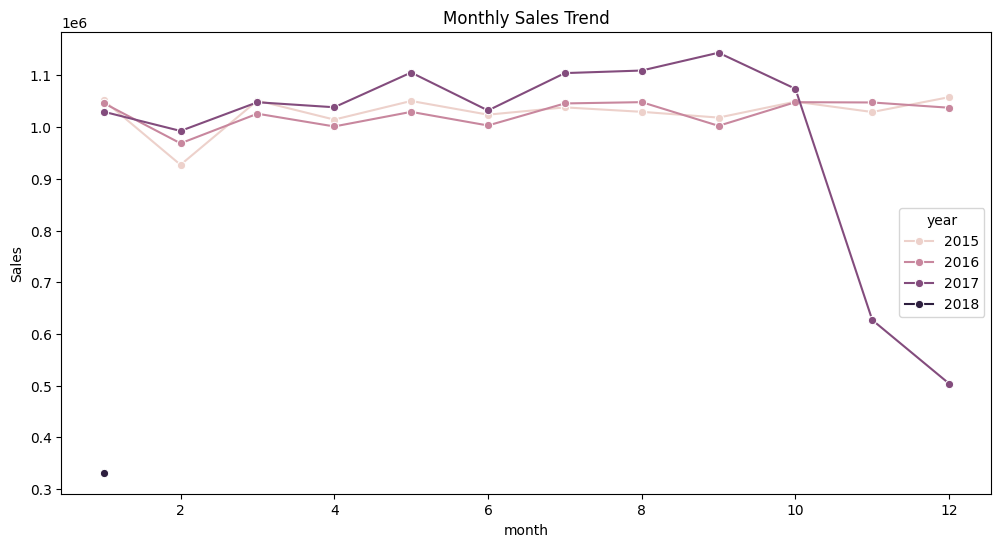

In [413]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['month'] = df['Order Date'].dt.month
df['year'] = df['Order Date'].dt.year

monthly_sales = df.groupby(['year','month'])['Sales'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_sales, x='month', y='Sales', hue='year', marker='o')
plt.title("Monthly Sales Trend")
plt.show()


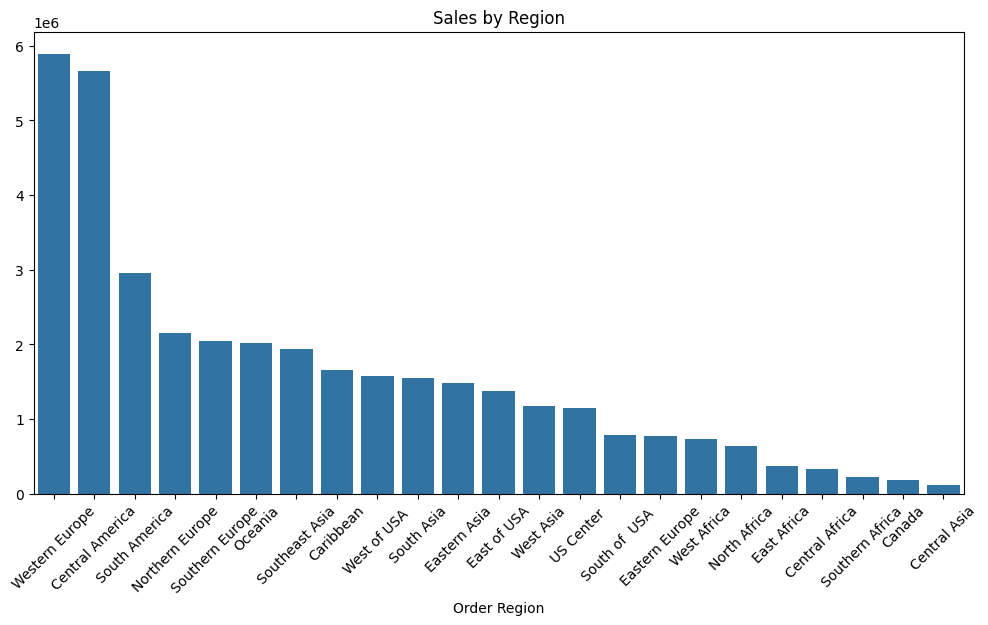

In [416]:
region_sales = df.groupby('Order Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title("Sales by Region")
plt.xticks(rotation=45)
plt.show()
